# Handwritten Character & Digit Recognition

Trains a convolutional neural network on handwritten characters.

**Datasets** (already downloaded to `./data`):

| Dataset | Split | Classes | Train / Test |
|---|---|---|---|
| MNIST | — | 10 digits | 60,000 / 10,000 |
| EMNIST | `balanced` | 47 (digits + upper + merged lowercase) | 112,800 / 18,800 |
| EMNIST | `byclass` | 62 (0-9, A-Z, a-z), unbalanced | 697,932 / 116,323 |
| EMNIST | `letters` | 26 letters | 124,800 / 20,800 |
| EMNIST | `digits` | 10 digits | 240,000 / 40,000 |

Change `DATASET` / `EMNIST_SPLIT` in the config cell to switch.

## 1. Setup

In [3]:
import os, time, random
import certifi
os.environ.setdefault("SSL_CERT_FILE", certifi.where())  # python.org macOS builds ship without CA certs

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchvision import datasets
from sklearn.metrics import confusion_matrix, classification_report

if torch.backends.mps.is_available():
    device = torch.device("mps")      # Apple Silicon GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("torch", torch.__version__, "| device:", device)

torch 2.14.1 | device: mps


In [4]:
# ---- Config ----
DATA_DIR     = "data"
DATASET      = "emnist"     # "mnist" or "emnist"
EMNIST_SPLIT = "balanced"   # balanced | byclass | bymerge | letters | digits | mnist
VAL_FRACTION = 0.1
BATCH_SIZE   = 256
EPOCHS       = 10
LR           = 1e-3
SEED         = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

## 2. Load data

EMNIST images are stored transposed relative to MNIST, so they're flipped back here. The whole dataset fits in memory as a tensor,
which is faster than per-sample transforms.

In [5]:
def load(train):
    if DATASET == "mnist":
        ds = datasets.MNIST(DATA_DIR, train=train, download=True)
        x = ds.data
    else:
        ds = datasets.EMNIST(DATA_DIR, split=EMNIST_SPLIT, train=train, download=True)
        x = ds.data.transpose(1, 2)  # fix EMNIST orientation
    return x.unsqueeze(1).float().div(255), ds.targets.long(), ds.classes

x_train_full, y_train_full, classes = load(train=True)
x_test, y_test, _ = load(train=False)

# EMNIST 'letters' labels are 1..26 with an unused 'N/A' class at index 0; drop it
if DATASET == "emnist" and EMNIST_SPLIT == "letters":
    classes = classes[1:]; y_train_full -= 1; y_test -= 1

MEAN, STD = x_train_full.mean().item(), x_train_full.std().item()
x_train_full = (x_train_full - MEAN) / STD
x_test = (x_test - MEAN) / STD

NUM_CLASSES = len(classes)
print(f"train {tuple(x_train_full.shape)}  test {tuple(x_test.shape)}  classes={NUM_CLASSES}")
print("labels:", "".join(classes) if all(len(c) == 1 for c in classes) else classes)

train (112800, 1, 28, 28)  test (18800, 1, 28, 28)  classes=47
labels: 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabdefghnqrt


In [6]:
full = TensorDataset(x_train_full, y_train_full)
n_val = int(len(full) * VAL_FRACTION)
train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=torch.Generator().manual_seed(SEED))
test_ds = TensorDataset(x_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=1024)
test_loader  = DataLoader(test_ds,  batch_size=1024)
print(len(train_ds), "train /", len(val_ds), "val /", len(test_ds), "test")

101520 train / 11280 val / 18800 test


## 3. Explore

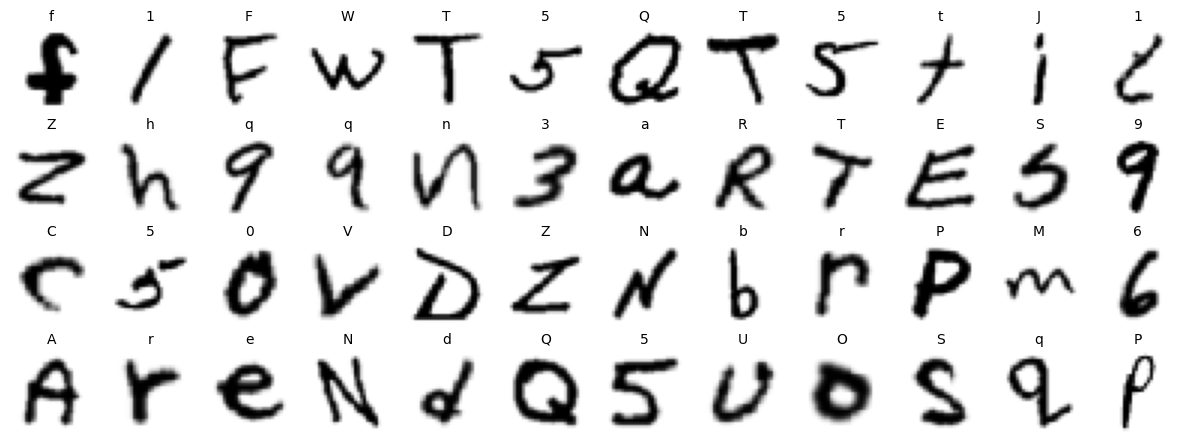

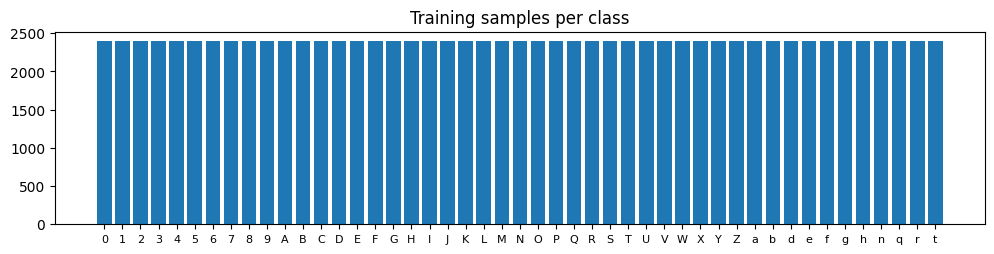

In [7]:
fig, axes = plt.subplots(4, 12, figsize=(12, 4.5))
idx = torch.randperm(len(x_train_full))[:48]
for ax, i in zip(axes.flat, idx):
    ax.imshow(x_train_full[i, 0] * STD + MEAN, cmap="gray_r")
    ax.set_title(classes[y_train_full[i]], fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

counts = torch.bincount(y_train_full, minlength=NUM_CLASSES)
plt.figure(figsize=(12, 2.5))
plt.bar(range(NUM_CLASSES), counts); plt.xticks(range(NUM_CLASSES), classes, fontsize=8)
plt.title("Training samples per class"); plt.show()

## 4. Model

A small VGG-style CNN: two conv blocks (28→14→7) followed by a fully connected classifier. Typically reaches ~99.5% on MNIST
and ~90% on EMNIST-balanced (the ceiling there is limited by genuinely ambiguous pairs like O/0, l/1, S/5).

In [8]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.Conv2d(cout, cout, 3, padding=1), nn.BatchNorm2d(cout), nn.ReLU(),
                nn.MaxPool2d(2), nn.Dropout(0.25),
            )
        self.features = nn.Sequential(block(1, 32), block(32, 64))
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64 * 7 * 7, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN(NUM_CLASSES).to(device)
print(model)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

CNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Dropout(p=0.25, inplace=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      

## 5. Train

In [9]:
def run_epoch(loader, train):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.cross_entropy(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item()
            n += len(yb)
    return total_loss / n, correct / n

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR * 3, epochs=EPOCHS, steps_per_epoch=len(train_loader))

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val, best_state = 0.0, None
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader, train=False)
    for k, v in zip(history, (tl, ta, vl, va)):
        history[k].append(v)
    if va > best_val:
        best_val, best_state = va, {k: v.detach().clone() for k, v in model.state_dict().items()}
    print(f"epoch {epoch:2d}  train {tl:.4f} / {ta:.2%}   val {vl:.4f} / {va:.2%}   ({time.time() - t0:.1f}s)")

model.load_state_dict(best_state)
print(f"best val acc: {best_val:.2%}")

epoch  1  train 1.5999 / 55.44%   val 0.5022 / 83.45%   (36.5s)
epoch  2  train 0.5999 / 79.94%   val 0.4243 / 85.52%   (32.1s)
epoch  3  train 0.5143 / 82.47%   val 0.3731 / 86.33%   (32.2s)
epoch  4  train 0.4316 / 84.82%   val 0.3406 / 88.13%   (33.1s)
epoch  5  train 0.3883 / 86.04%   val 0.3072 / 89.07%   (31.5s)
epoch  6  train 0.3591 / 86.97%   val 0.2995 / 89.47%   (31.9s)
epoch  7  train 0.3284 / 88.14%   val 0.2926 / 89.57%   (35.4s)
epoch  8  train 0.3049 / 88.78%   val 0.2790 / 90.21%   (33.0s)
epoch  9  train 0.2855 / 89.41%   val 0.2761 / 90.11%   (31.5s)
epoch 10  train 0.2753 / 89.79%   val 0.2759 / 90.27%   (31.3s)
best val acc: 90.27%


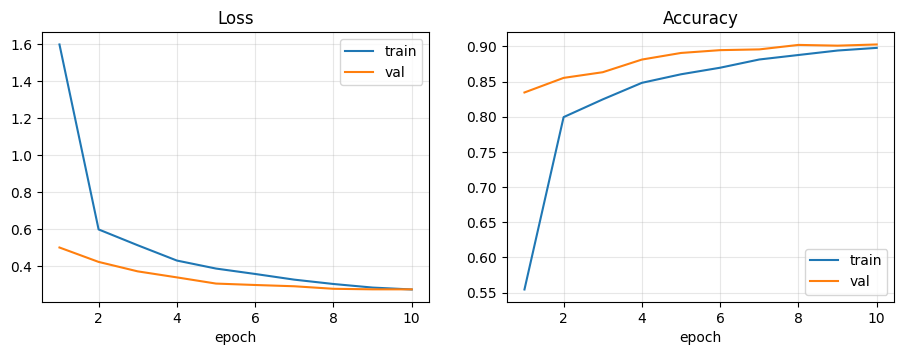

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
ep = range(1, len(history["train_loss"]) + 1)
a1.plot(ep, history["train_loss"], label="train"); a1.plot(ep, history["val_loss"], label="val"); a1.set_title("Loss")
a2.plot(ep, history["train_acc"], label="train"); a2.plot(ep, history["val_acc"], label="val"); a2.set_title("Accuracy")
for a in (a1, a2): a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
plt.show()

## 6. Evaluate on the test set

In [11]:
@torch.no_grad()
def predict(loader):
    model.eval()
    preds = [model(xb.to(device)).argmax(1).cpu() for xb, _ in loader]
    return torch.cat(preds)

y_pred = predict(test_loader)
print(f"Test accuracy: {(y_pred == y_test).float().mean():.2%}\n")
print(classification_report(y_test, y_pred, target_names=classes, digits=3))

Test accuracy: 89.94%

              precision    recall  f1-score   support

           0      0.655     0.755     0.702       400
           1      0.582     0.752     0.656       400
           2      0.943     0.902     0.922       400
           3      0.997     0.983     0.990       400
           4      0.966     0.938     0.952       400
           5      0.951     0.915     0.932       400
           6      0.955     0.958     0.956       400
           7      0.975     0.988     0.981       400
           8      0.954     0.975     0.964       400
           9      0.697     0.853     0.767       400
           A      0.975     0.995     0.985       400
           B      0.978     0.983     0.980       400
           C      0.968     0.968     0.968       400
           D      0.946     0.925     0.936       400
           E      0.983     0.988     0.985       400
           F      0.737     0.588     0.654       400
           G      0.944     0.973     0.958       400
    

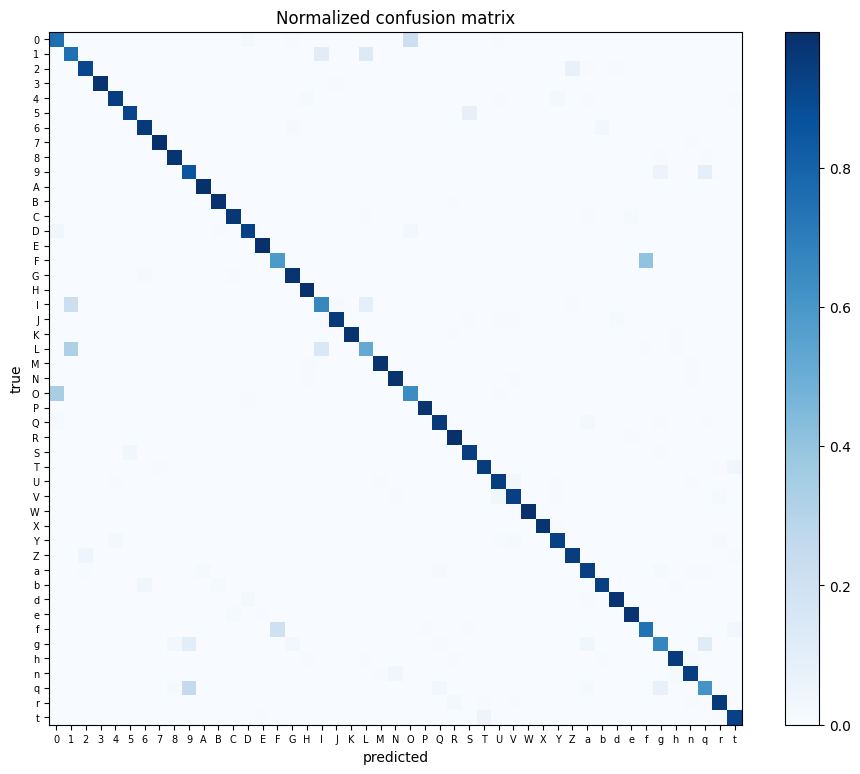

  'F' -> 'f'   40.2%
  'O' -> '0'   34.0%
  'L' -> '1'   32.5%
  'q' -> '9'   25.2%
  'I' -> '1'   21.5%
  '0' -> 'O'   21.2%
  'f' -> 'F'   20.5%
  'L' -> 'I'   14.2%
  '1' -> 'L'   13.0%
  'g' -> 'q'   11.8%


In [12]:
cm = confusion_matrix(y_test, y_pred, normalize="true")
plt.figure(figsize=(11, 9))
plt.imshow(cm, cmap="Blues"); plt.colorbar(fraction=0.046)
plt.xticks(range(NUM_CLASSES), classes, fontsize=7); plt.yticks(range(NUM_CLASSES), classes, fontsize=7)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Normalized confusion matrix"); plt.show()

# most-confused pairs
off = cm.copy(); np.fill_diagonal(off, 0)
for i in np.argsort(off, axis=None)[::-1][:10]:
    t, p = divmod(i, NUM_CLASSES)
    print(f"{classes[t]!r:>5} -> {classes[p]!r:<5} {off[t, p]:.1%}")

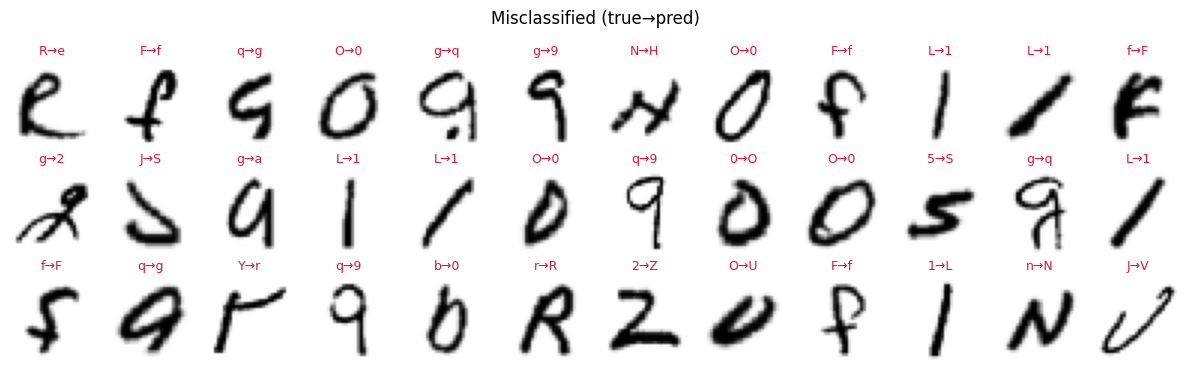

In [13]:
wrong = (y_pred != y_test).nonzero().squeeze(1)
sel = wrong[torch.randperm(len(wrong))[:36]]
fig, axes = plt.subplots(3, 12, figsize=(12, 3.8))
for ax, i in zip(axes.flat, sel):
    ax.imshow(x_test[i, 0] * STD + MEAN, cmap="gray_r")
    ax.set_title(f"{classes[y_test[i]]}→{classes[y_pred[i]]}", fontsize=9, color="crimson"); ax.axis("off")
plt.suptitle("Misclassified (true→pred)"); plt.tight_layout(); plt.show()

## 7. Save

In [14]:
os.makedirs("models", exist_ok=True)
path = f"models/cnn_{DATASET}_{EMNIST_SPLIT if DATASET == 'emnist' else 'digits'}.pt"
torch.save({"state_dict": model.state_dict(), "classes": classes, "mean": MEAN, "std": STD}, path)
print("saved", path)

saved models/cnn_emnist_balanced.pt


## Next steps
- **Data augmentation** (small rotations/shifts/elastic distortion) usually adds ~0.5–1% on EMNIST.
- **Bigger model** (ResNet-style blocks) or longer training.
- **Full handwritten text lines/words**: move from single-character classification to a CRNN + CTC loss trained on a line-level dataset such as IAM
  (requires free registration at fki.tic.heia-fr.ch/databases/iam-handwriting-database).